## Environment Validation

This cell validates the environment for annotation tasks. The system checks:
- Python packages required for annotation workflow
- Access to preprocessing outputs
- Directory structure for annotations
- JSON configuration handling

In [2]:
import sys
import json
import os
import shutil
from pathlib import Path
import importlib

print(f"Python: {sys.version}")

# check packages
required_packages = ['cv2', 'numpy', 'json', 'yaml']
for package in required_packages:
    try:
        if package == 'yaml':
            importlib.import_module('yaml')
        else:
            importlib.import_module(package)
        print(f"✓ {package}")
    except ImportError:
        print(f"✗ {package} - Missing")

# verify dirs
dirs = ['data/annotations', 'data/annotations/images', 'data/annotations/labels']
for dir_path in dirs:
    Path(dir_path).mkdir(parents=True, exist_ok=True)
    print(f"✓ {dir_path}")

Python: 3.12.9 | packaged by Anaconda, Inc. | (main, Feb  6 2025, 18:56:27) [GCC 11.2.0]
✓ cv2
✓ numpy
✓ json
✓ yaml
✓ data/annotations
✓ data/annotations/images
✓ data/annotations/labels



## Set Working Directory

This cell changes the working directory to the project root. This ensures:
- All file paths are relative to the project root
- Preprocessing outputs are accessible
- Annotation data saves to correct location

In [3]:
import os
from pathlib import Path

# set project root
project_root = Path('/home/trauco/experiments-test')

# change to root
os.chdir(project_root)
print(f"Project root: {os.getcwd()}")

# verify
for path in ['data/clips', 'data/frames', 'data/annotations', 'configs']:
    exists = Path(path).exists()
    print(f"{'✓' if exists else '✗'} {path}")

Project root: /home/trauco/experiments-test
✓ data/clips
✓ data/frames
✓ data/annotations
✓ configs


## Load Preprocessing Configuration

This cell loads the most recent preprocessing configuration. The process:
- Scans configs directory for preprocessing JSON files
- Loads the most recent configuration
- Displays preprocessing parameters used
- Verifies frame paths exist

In [5]:
import json
import glob
from datetime import datetime

# find configs
config_files = sorted(glob.glob('configs/preprocessing_*.json'))

if not config_files:
    print("✗ No preprocessing configs found")
    print("Run preprocessing notebook first")
else:
    # load latest
    latest_config = config_files[-1]
    print(f"Loading: {latest_config}")
    
    with open(latest_config, 'r') as f:
        preprocessing_config = json.load(f)
    
    # show info
    print(f"\nPreprocessing info:")
    print(f"  Camera: {preprocessing_config['camera_id']}")
    print(f"  Timestamp: {preprocessing_config['processing_timestamp']}")
    print(f"  Frame count: {preprocessing_config['frame_count']}")
    print(f"  Method: {preprocessing_config['preprocessing_method']}")
    print(f"  Frames dir: {preprocessing_config['frames_dir']}")

Loading: configs/preprocessing_20250623_004552.json

Preprocessing info:
  Camera: ATL-0610
  Timestamp: 20250623_004552
  Frame count: 129
  Method: diff
  Frames dir: data/frames/ATL-0610_20250623_004552


## Select Frames for Annotation

This cell selects a subset of frames for annotation. The process:
- Takes every Nth frame to get 30-60 frames
- Copies selected frames to annotation directory
- Creates frame list for CVAT upload
- Displays sample of selected frames

Selecting every 3 frames

✓ Copied 40 frames to data/annotations/images


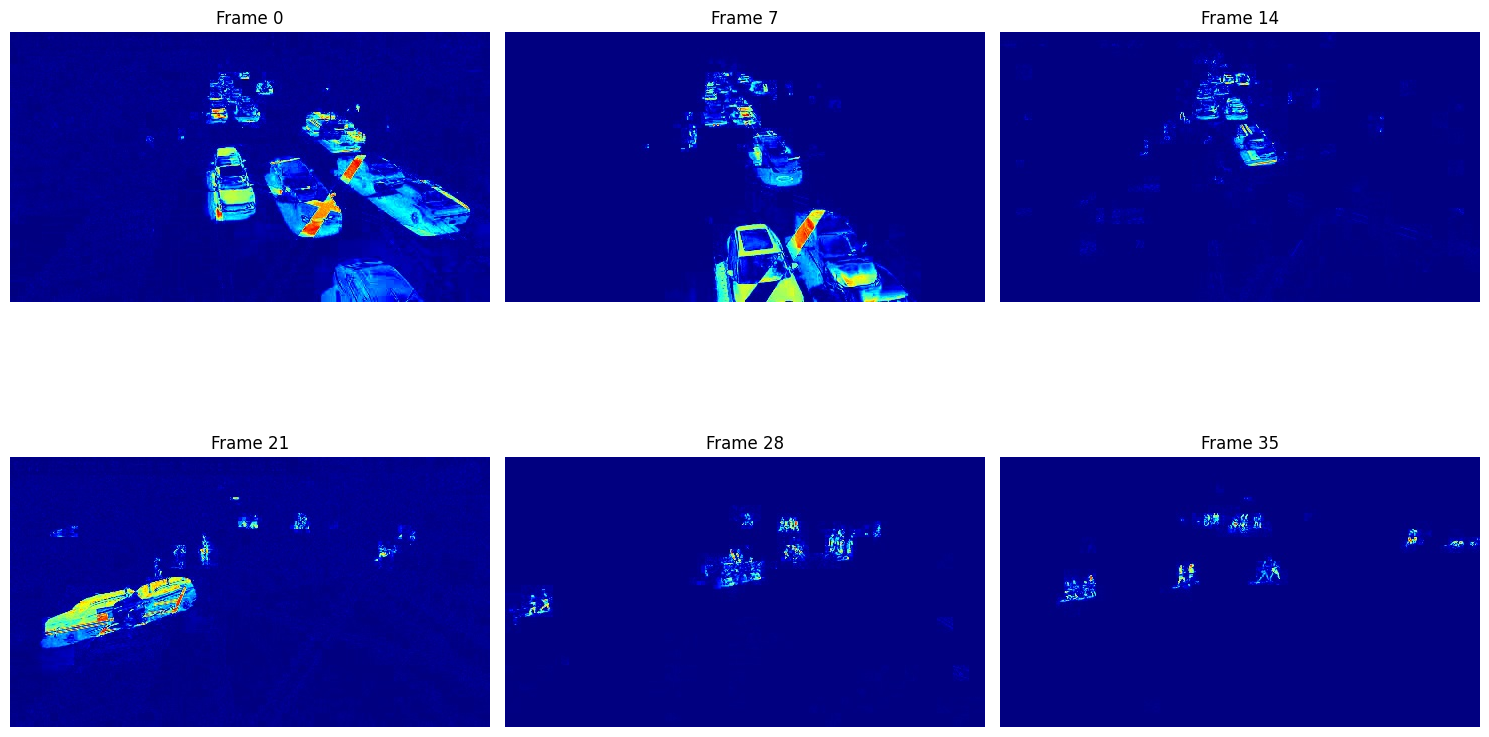

In [6]:
import shutil
import cv2
import matplotlib.pyplot as plt

# select subset
total_frames = preprocessing_config['frame_count']
target_count = 40  # aim for 40 frames

# calc interval
interval = max(1, total_frames // target_count)
print(f"Selecting every {interval} frames")

# get frame paths
frame_paths = sorted(Path(preprocessing_config['frames_dir']).glob('*.jpg'))
selected_frames = frame_paths[::interval][:target_count]

# copy to annotation dir
annotation_images_dir = Path('data/annotations/images')
annotation_images_dir.mkdir(parents=True, exist_ok=True)

# clear old
for old_file in annotation_images_dir.glob('*.jpg'):
    old_file.unlink()

# copy selected
for i, frame_path in enumerate(selected_frames):
    dest_path = annotation_images_dir / f"frame_{i:04d}.jpg"
    shutil.copy2(frame_path, dest_path)

print(f"\n✓ Copied {len(selected_frames)} frames to {annotation_images_dir}")

# preview
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for idx, ax in enumerate(axes.flat):
    if idx < 6:
        img = cv2.imread(str(selected_frames[idx * 7]))  # spread samples
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        ax.imshow(img_rgb)
        ax.set_title(f"Frame {idx * 7}")
        ax.axis('off')
    else:
        ax.axis('off')

plt.tight_layout()
plt.show()

## CVAT Annotation Instructions

This section provides instructions for annotating frames in CVAT. Follow these steps:
- Upload frames from data/annotations/images/ to CVAT
- Create labels for vehicle classes
- Annotate all moving vehicles
- Export annotations in YOLO format

In [8]:
# annotation params
annotation_params = {
    'image_dir': str(annotation_images_dir),
    'frame_count': len(selected_frames),
    'classes': ['vehicle'],  # single class for now
    'annotation_type': 'bounding_box',
    'export_format': 'YOLO 1.1'
}

print("CVAT Task Setup:")
print(f"  Images: {annotation_params['image_dir']}")
print(f"  Frame count: {annotation_params['frame_count']}")
print(f"  Classes: {annotation_params['classes']}")
print(f"\nSteps:")
print("1. Open CVAT at http://localhost:8081")
print("2. Create new task")
print("3. Upload all images from data/annotations/images/")
print("4. Add label: 'vehicle'")
print("5. Annotate all moving vehicles with bounding boxes")
print("6. Export as 'YOLO 1.1' format")
print("7. Extract zip to data/annotations/")

CVAT Task Setup:
  Images: data/annotations/images
  Frame count: 40
  Classes: ['vehicle']

Steps:
1. Open CVAT at http://localhost:8081
2. Create new task
3. Upload all images from data/annotations/images/
4. Add label: 'vehicle'
5. Annotate all moving vehicles with bounding boxes
6. Export as 'YOLO 1.1' format
7. Extract zip to data/annotations/


## Annotation Guidelines

Annotation focused on foreground vehicles only:

![Annotation cutoff line](../data/annotations/docs/cutoff.png)

### Rules Applied:
- Annotated vehicles before red line only
- Skipped distant vehicles 
- Included partial vehicles entering/exiting frame
- Targeted clear motion signatures

This approach provided quality training data for baseline vehicle detection.

## Motion Detection via Frame Differencing

Frame differencing generates heatmaps highlighting pixel changes between consecutive frames. Technical details:

### Testing Frame Differencing for Low-Res Video
- Input: 480x270 @ 15fps traffic camera footage
- Low resolution presents challenges for traditional object detection
- Testing motion-based approach to enhance moving objects
- Difference calculation attempts to isolate movement from static background

### Heatmap Interpretation
- Blue/Black: Static areas (no motion)
- Yellow/Red: High motion areas (moving vehicles)
- Intensity correlates with movement speed/magnitude
- Each bright blob represents vehicle displacement between frames

### Hypothesis for Vehicle Detection
- Static background removal may improve detection
- Motion signatures could help identify vehicles in poor quality footage
- Simplified annotation process for baseline testing
- Evaluating effectiveness for counting tasks

This experiment tests whether frame differencing can improve vehicle detection in challenging low-resolution traffic footage.

## Import and Extract CVAT Annotations

This cell processes the CVAT export file. The workflow:
- Locates the downloaded YOLO format export
- Creates organized directory structure 
- Copies zip to cvat_exports/ for archival
- Extracts annotations to yolo_format/ for training
- Displays extracted file structure

In [9]:
import zipfile
import shutil
from pathlib import Path

# paths
cvat_export_zip = Path('data/annotations/ATL-0610-diff-40f-yolo.zip')
annotations_dir = Path('data/annotations')
cvat_exports_dir = annotations_dir / 'cvat_exports'
extracted_dir = annotations_dir / 'yolo_format'

# create dirs
cvat_exports_dir.mkdir(parents=True, exist_ok=True)
extracted_dir.mkdir(parents=True, exist_ok=True)

# verify zip exists
if cvat_export_zip.exists():
    # copy to exports dir
    dest_zip = cvat_exports_dir / cvat_export_zip.name
    shutil.copy2(cvat_export_zip, dest_zip)
    print(f"✓ Found export: {cvat_export_zip}")
    print(f"✓ Copied to: {dest_zip}")
    
    # clean extract dir
    if extracted_dir.exists():
        shutil.rmtree(extracted_dir)
    extracted_dir.mkdir()
    
    # extract
    with zipfile.ZipFile(cvat_export_zip, 'r') as zip_ref:
        zip_ref.extractall(extracted_dir)
    print(f"✓ Extracted to: {extracted_dir}")
    
    # list contents
    print("\nExtracted contents:")
    for item in sorted(extracted_dir.rglob('*')):
        if item.is_file():
            print(f"  - {item.relative_to(extracted_dir)}")
else:
    print(f"✗ Export file not found: {cvat_export_zip}")

✓ Found export: data/annotations/ATL-0610-diff-40f-yolo.zip
✓ Copied to: data/annotations/cvat_exports/ATL-0610-diff-40f-yolo.zip
✓ Extracted to: data/annotations/yolo_format

Extracted contents:
  - Train/labels.json
  - Train/no_label/frame_0000.jpg
  - Train/no_label/frame_0001.jpg
  - Train/no_label/frame_0002.jpg
  - Train/no_label/frame_0003.jpg
  - Train/no_label/frame_0004.jpg
  - Train/no_label/frame_0005.jpg
  - Train/no_label/frame_0006.jpg
  - Train/no_label/frame_0007.jpg
  - Train/no_label/frame_0008.jpg
  - Train/no_label/frame_0009.jpg
  - Train/no_label/frame_0010.jpg
  - Train/no_label/frame_0011.jpg
  - Train/no_label/frame_0012.jpg
  - Train/no_label/frame_0013.jpg
  - Train/no_label/frame_0014.jpg
  - Train/no_label/frame_0015.jpg
  - Train/no_label/frame_0016.jpg
  - Train/no_label/frame_0017.jpg
  - Train/no_label/frame_0018.jpg
  - Train/no_label/frame_0019.jpg
  - Train/no_label/frame_0020.jpg
  - Train/no_label/frame_0021.jpg
  - Train/no_label/frame_0022.jpg


## Create Training Configuration

This cell creates the minimal configuration needed for YOLO training.

In [11]:
import yaml

# create data.yaml for yolo
data_config = {
    'path': str(Path.cwd() / 'data/annotations/yolo_format'),
    'train': 'images',
    'val': 'images',  # using same for quick test
    'names': {
        0: 'vehicle'
    }
}

# save yaml
yaml_path = Path('data/annotations/yolo_format/data.yaml')
with open(yaml_path, 'w') as f:
    yaml.dump(data_config, f)

print(f"✓ Created: {yaml_path}")

# save annotation config
annotation_config = {
    'timestamp': datetime.now().strftime("%Y%m%d_%H%M%S"),
    'preprocessing_config': latest_config,
    'annotation_method': 'cvat_manual',
    'frame_count': 40,
    'yaml_path': str(yaml_path),
    'export_path': str(extracted_dir)
}

config_path = Path('configs') / f"annotation_{annotation_config['timestamp']}.json"
with open(config_path, 'w') as f:
    json.dump(annotation_config, f, indent=2)

print(f"✓ Saved config: {config_path}")
print("\nReady for training!")

✓ Created: data/annotations/yolo_format/data.yaml
✓ Saved config: configs/annotation_20250623_021049.json

Ready for training!
